In [1]:
import argparse
import torch
import torch.nn as nn
import os
import pandas as pd
from tqdm import tqdm
from sklearn import metrics
import seaborn as sns
from benchmark.Promoterformer.data import BurstformerDataset
from benchmark.Promoterformer.net import  ChromoformerClassifier
from src.utils.tools import seed_everything
from src.utils.constants import DEVICE
from benchmark.Promoterformer.constants import get_config
from copy import deepcopy
from src.utils.logs import get_logger
import matplotlib.pyplot as plt
from matplotlib import rcParams, rcParamsDefault



logger = get_logger()

torch.autograd.set_detect_anomaly(True)

def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group["lr"]

#
# Training setup.
#
    
def evaluation(out:'torch.Tensor', label:'torch.Tensor'):
    score = out.softmax(axis=1)[:, 1]
    pred = out.argmax(axis=1)

    acc = metrics.accuracy_score(label, pred) * 100
    auc = metrics.roc_auc_score(label, score) * 100
    ap = metrics.average_precision_score(label, score) * 100
    return score, label, pred, acc, auc, ap

config_path = "benchmark/Promoterformer/configs/default.yaml"
config = get_config(config_path)
add_feature_bin = False



feature_bin_kws = config['feature_bin_kws']
seed = config["seed"]

bsz = config["bsz"]
gamma = config["gamma"]

i_max = config["i_max"]
w_prom = config["w_prom"]
w_max = config["w_max"]

n_feats_pcres = config['pcres_feats_basic_nums'] 
d_emb = config["embed"]["d_model"]
embed_kws = config["embed"]
pairwise_interaction_kws = config["pairwise_interaction"]
regulation_kws = config["regulation"]
d_head = config["d_head"]
targets = ['bs_label','bf_label']
npy_dir = "extra/datasets/processed/v1"





/Users/wanghan/miniforge3/envs/burstformer/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:

binsizes = [500]

# eid = "E116"
# fold = 0
MARKS = ["H3K4me1","H3K4me3","H3K9me3","H3K27me3","H3K36me3","H3K27ac","H3K9ac"]
predictions = []
for eid in ["E116","E118","E003"]:
    for keep_mark in MARKS:
        remove_marks = deepcopy(MARKS)
        remove_marks.remove(keep_mark)
        logger.info(remove_marks)
        for fold in [0,1,2,3]:
            logger.info(f"{eid} {keep_mark} {fold}")

            checkpoints = f"benchmark/Promoterformer/checkpoints/{eid}.remove_{'_'.join(remove_marks)}.{fold}.No_feature_bin.model.pt"

            meta_path = f"extra/datasets/processed/v1/meta_datasets/meta_data_{eid}.csv"
            config["remove_marks"] = remove_marks
            n_feats_p = config['promoter_feats_basic_nums'] - len(config["remove_marks"])  + feature_bin_kws['out_channels'] if add_feature_bin else config['promoter_feats_basic_nums'] - len(config["remove_marks"])


            seed_everything(seed)
            meta = (
                pd.read_csv(meta_path).sample(frac=1, random_state=seed).reset_index(drop=True)
            )  # load and shuffle.

            # Split genes into two sets (train/val).
            genes = set(meta.gene_id.unique())
            n_genes = len(genes)
            print("Target genes:", len(genes))
            print(f"n_feats_p:{n_feats_p}")

            splits = {
                1: ['chr1', 'chr6', 'chr5', 'chr8', 'chr14', 'chrY'],
                2: ['chr7', 'chr10', 'chr11', 'chr12', 'chr15', 'chr21'],
                3: ['chr2', 'chr3', 'chr4', 'chr16', 'chr18', 'chr20'],
                4: ['chr9', 'chr13', 'chr17', 'chr19', 'chr22', 'chrX'],
            }

            chromosome_splits = {}
            for key, chroms in splits.items():
                for chrom in chroms:
                    chromosome_splits[chrom] = key

            qs = [
                meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 1,axis=1)].gene_id.tolist(),
                meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 2,axis=1)].gene_id.tolist(),
                meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 3,axis=1)].gene_id.tolist(),
                meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 4,axis=1)].gene_id.tolist(),
            ]

            train_genes = (
                qs[(fold + 0) % 4] + qs[(fold + 1) % 4] + qs[(fold + 2) % 4]
            )
            val_genes = qs[(fold + 3) % 4]

            print(len(train_genes), len(val_genes))

            val_dataset = BurstformerDataset(
                meta_path,
                npy_dir,
                val_genes,
                i_max,
                binsizes,
                w_prom,
                w_max,
                targets=targets,
                config = config,
                with_gene_id=True
            )
            val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=bsz)

            model = ChromoformerClassifier(
                n_feats_p,
                n_feats_pcres,
                d_emb,
                d_head,
                feature_bin_kws=feature_bin_kws,
                embed_kws=embed_kws,
                binsizes=binsizes,
                seed=42,
                targets=targets,
                add_feature_bin = add_feature_bin,
            ).to(DEVICE)

            ckpt = torch.load(checkpoints,map_location=DEVICE)
            model.load_state_dict(ckpt["net"])

            # bf Test data evaluation
            # Prepare validation.
            bar = tqdm(enumerate(val_loader, 1), total=len(val_loader))
            gene_ids, val_out, val_label = [], [], []


            # Validation.
            model.eval()
            with torch.no_grad():
                for batch, d in bar:
                    gene_ids += d.pop('gene_id')
                    for k, v in d.items():
                        if isinstance(v, dict):
                            for _k, _v in v.items():
                                v[_k] = _v.to(DEVICE)
                        else:
                            d[k] = v.to(DEVICE)

                    out = model(
                        d["promoter_feats"][500],
                        d["promoter_pad_masks"][500],
                    )
                    val_out.append(out.cpu())

                    val_label.append(d["label"].cpu())

            val_out = torch.cat(val_out)
            val_label = torch.cat(val_label)


            val_preds = {}
            for target, pred in zip(targets,torch.chunk(val_out, len(targets), axis=-1)):
                val_preds[target] = pred
            
            val_labels = {}
            for target, label in zip(targets,torch.chunk(val_label, len(targets), axis=-1)):
                val_labels[target] = label   

            # Metrics.

            ckpt['gene_id'] = gene_ids
            description = ""
            records = {}
            records['gene_id'] = gene_ids
            records['keep_mark'] = keep_mark
            records['eid'] = eid
            for target in targets:
                val_score, val_label, val_pred, val_acc, val_auc, val_ap = evaluation(val_preds[target],val_labels[target])

                ckpt[f'{target}_label'] = val_label
                ckpt[f'{target}_score'] = val_score
                ckpt[f'{target}_pred'] = val_pred
                ckpt[f'{target}_val_acc'] = val_acc
                ckpt[f'{target}_val_auc'] = val_auc
                ckpt[f'{target}_val_ap'] = val_ap 

                records[f'{target}_label'] = val_label.cpu().numpy().squeeze()
                records[f'{target}_score'] = val_score.cpu().numpy().squeeze()
                records[f'{target}_pred'] = val_pred.cpu().numpy().squeeze()     
                description += f"{target}: acc={val_acc:.4f}, auc={val_auc:.4f}, ap={val_ap:.4f} " 
            
            records['fold'] = fold
            df = pd.DataFrame(records)
            predictions.append(df)

            print(description)

            torch.save(ckpt, checkpoints)

predictions = pd.concat(predictions,axis=0)
predictions.to_csv(f'extra/datasets/benchmark/Promoterformer/results/one_feature_predictions.csv',index=False)

-2025-02-17 15:26:19,075-INFO ['H3K4me3', 'H3K9me3', 'H3K27me3', 'H3K36me3', 'H3K27ac', 'H3K9ac']
-2025-02-17 15:26:19,077-INFO E116 H3K4me1 0


Target genes: 15641
n_feats_p:1
11826 3815


100%|██████████| 60/60 [00:22<00:00,  2.71it/s]
-2025-02-17 15:26:41,687-INFO E116 H3K4me1 1


bs_label: acc=70.9567, auc=77.5621, ap=73.5909 bf_label: acc=83.4862, auc=91.2671, ap=90.2615 
Target genes: 15641
n_feats_p:1
11439 4202


100%|██████████| 66/66 [00:23<00:00,  2.78it/s]
-2025-02-17 15:27:05,926-INFO E116 H3K4me1 2


...

bs_label: acc=67.0817, auc=71.7290, ap=67.0978 bf_label: acc=86.6667, auc=92.2434, ap=91.1950 
Target genes: 14304
n_feats_p:1
10790 3514


100%|██████████| 55/55 [00:19<00:00,  2.83it/s]
-2025-02-17 15:55:29,249-INFO E003 H3K9ac 3


bs_label: acc=68.3267, auc=73.7755, ap=69.2026 bf_label: acc=87.0233, auc=93.0858, ap=92.2142 
Target genes: 14304
n_feats_p:1
10854 3450


100%|██████████| 54/54 [00:18<00:00,  2.85it/s]


bs_label: acc=67.5652, auc=71.1103, ap=69.0231 bf_label: acc=87.1594, auc=93.0107, ap=93.4249 


In [4]:
rcParams.update(rcParamsDefault)
rcParams['pdf.fonttype'] = 42
sns.set(context = 'paper' , style='ticks' , 
    rc = {
        'figure.autolayout' : True,
        'font.sans-serif': ['Arial', 'Helvetica'],  # Specify Arial or Helvetica
        'axes.titlesize' : 8 ,
        'axes.titleweight' :'bold',
        'axes.titlesize': 10,  # Title font size
        
        'figure.titleweight' : 'bold' ,
        'figure.titlesize' : 8 ,
        
        'axes.labelsize' : 10 ,
        'axes.labelpad' : 2 ,
        # 'axes.labelweight' : 'bold' , 
        'axes.spines.top' : False,
        'axes.spines.right' : False,
        
        'xtick.labelsize' : 7 ,
        'ytick.labelsize' : 7 ,
        
        'legend.fontsize' : 8 ,
        'figure.figsize' : (16/2.54, 8/2.54) , 
        'figure.dpi': 300,      
        'figure.facecolor': 'w',
        'figure.edgecolor': 'k',   
        
        'xtick.direction' : 'out' ,
        'ytick.direction' : 'out' ,
        
        'xtick.major.size' : 2 ,
        'ytick.major.size' : 2 ,
        'xtick.minor.size': 2,  # X-axis minor tick length
        'ytick.minor.size': 2,  # Y-axis minor tick length

        'xtick.major.pad' : 2,
        'ytick.major.pad' : 2,
        
        'lines.linewidth' : 0.75  , 
        'axes.linewidth': 0.5,  # Axis line width
        'savefig.dpi': 300,  # Save resolution 
        'savefig.bbox': 'tight',  # Tight bounding box       
        }
    )

sns.set_palette("colorblind")

In [5]:
MARKS = ["H3K4me1","H3K4me3","H3K9me3","H3K27me3","H3K36me3","H3K27ac","H3K9ac"]
predictions = []
with open('extra/datasets/benchmark/Promoterformer/results/one_feature_indicators.csv','w') as w:
    line = ['eid','keep_mark','fold','auc','target']
    w.write(','.join(line) + '\n')
    for eid in ["E116","E118","E003"]:
        for keep_mark in MARKS:
            remove_marks = deepcopy(MARKS)
            remove_marks.remove(keep_mark)
            
            for fold in [0,1,2,3]:
                checkpoints = f"benchmark/Promoterformer/checkpoints/{eid}.remove_{'_'.join(remove_marks)}.{fold}.No_feature_bin.model.pt"
                ckpt = torch.load(checkpoints,map_location=DEVICE)
                for target in targets:
                    auc = ckpt[f"{target}_val_auc"]
                    line = [eid,keep_mark,str(fold),str(auc),target]
                    w.write(','.join(line) + '\n')

data = pd.read_csv('extra/datasets/benchmark/Promoterformer/results/one_feature_indicators.csv')
data

,eid,keep_mark,fold,auc,target
0,E116,H3K4me1,0,77.562077,bs_label
1,E116,H3K4me1,0,91.267089,bf_label
2,E116,H3K4me1,1,77.331183,bs_label
3,E116,H3K4me1,1,92.768745,bf_label
4,E116,H3K4me1,2,79.249251,bs_label
...,...,...,...,...,...
163,E003,H3K9ac,1,92.243379,bf_label
164,E003,H3K9ac,2,73.775451,bs_label
165,E003,H3K9ac,2,93.085816,bf_label
166,E003,H3K9ac,3,71.110264,bs_label


In [ ]:
data = pd.read_csv('extra/datasets/benchmark/Promoterformer/results/one_feature_indicators.csv')
data

## BS one-feature ablation

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_80246/150281968.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right',fontdict={'size':8})  # ha参数用于设置水平对齐方式
-2025-02-17 16:19:50,531-WARNING The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


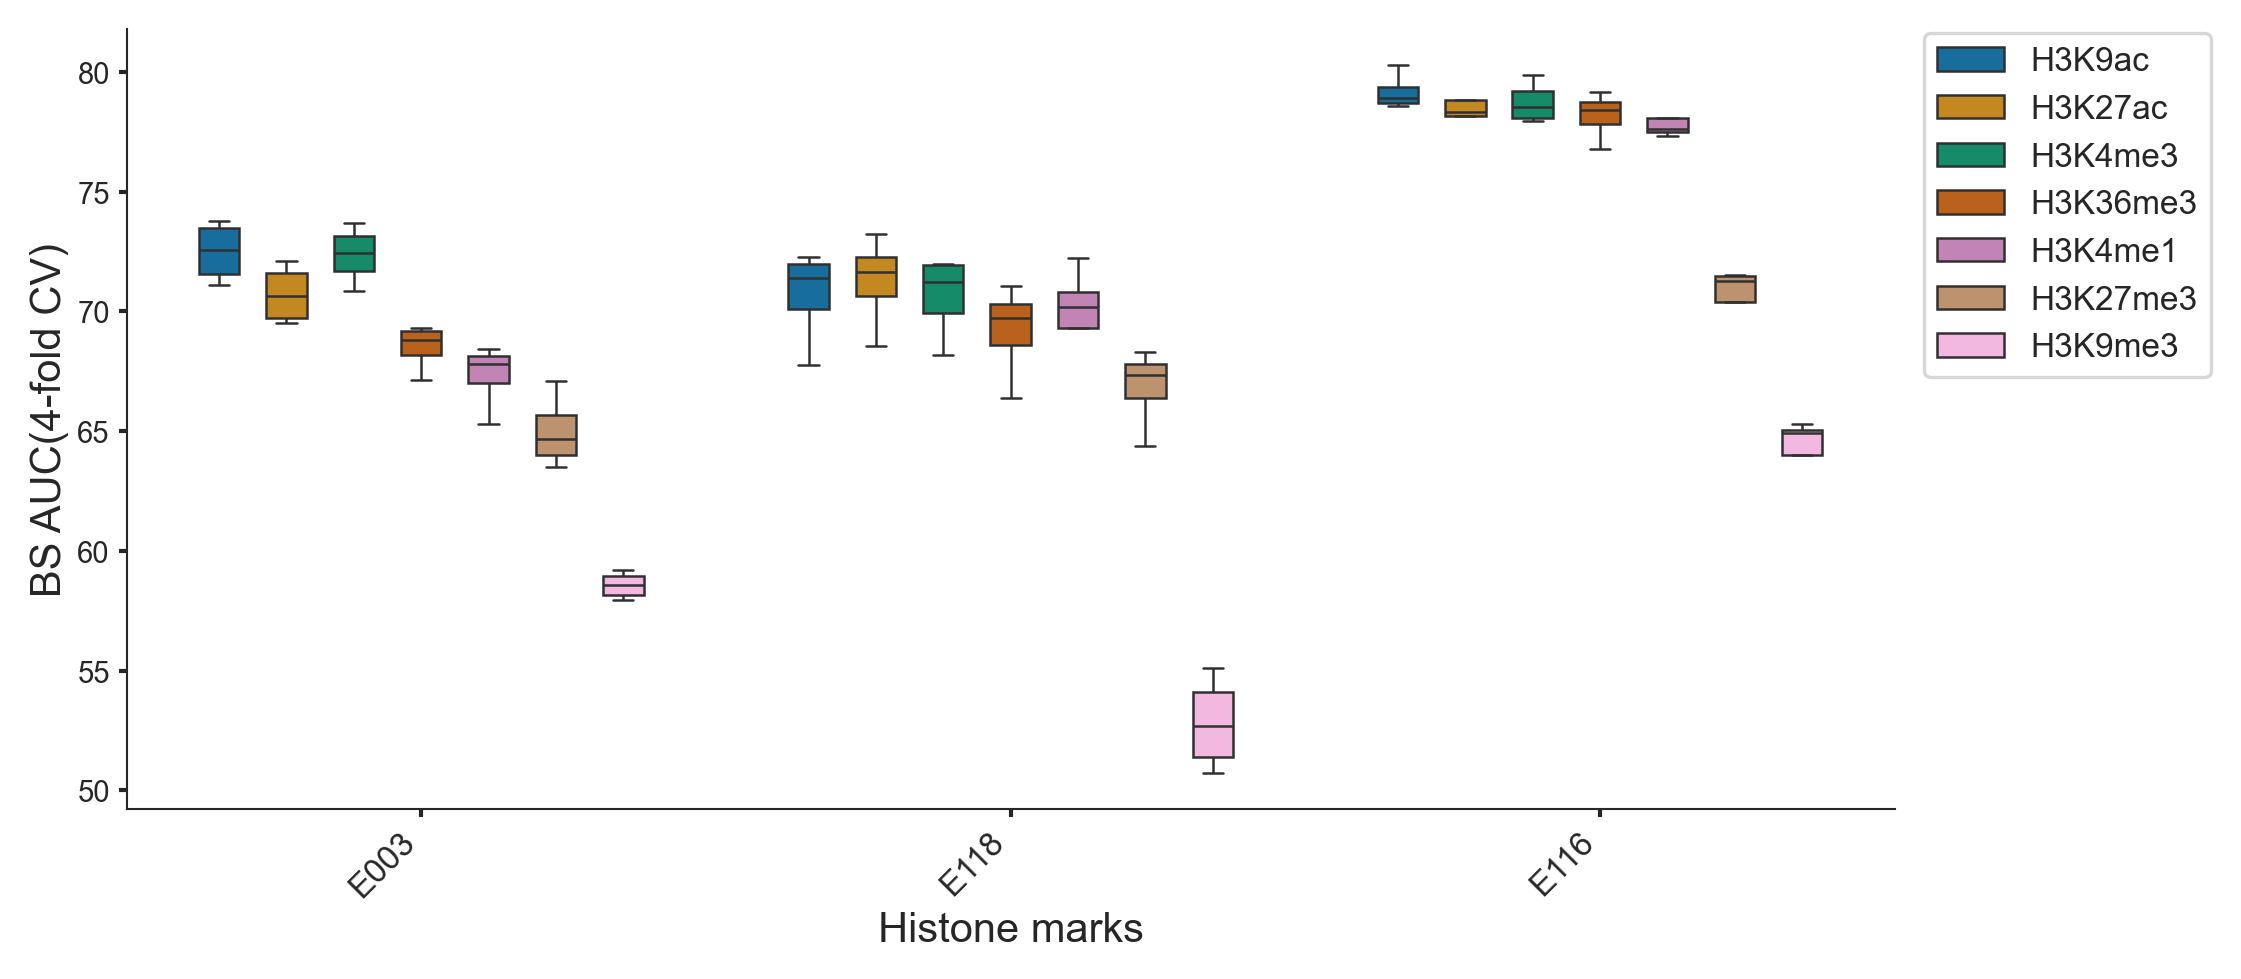

In [15]:
# 设置为 colorblind 调色板
# sns.set_palette("colorblind")
# sns.set_context("paper") 

df = data[data['target'] == 'bs_label']
# fig=plt.figure(figsize=(3.6,3.6) , dpi= 300, facecolor='w', edgecolor='k')
# fig.tight_layout(pad = 1)
fig, ax = plt.subplots(1,1,constrained_layout=True)
hue_order = pd.Index(["H3K9ac","H3K27ac","H3K4me3","H3K36me3","H3K4me1","H3K27me3","H3K9me3"],name='marks')
order = pd.Index(["E003","E118","E116"],name='marks')
ax = sns.boxplot(data=df,y='auc',x='eid',hue='keep_mark',gap=0.4,width=0.8,fliersize=0,order=order,hue_order=hue_order,linewidth=0.6)
plt.ylabel(f'BS AUC(4-fold CV)')
plt.xlabel(f'Histone marks')
# ax.set_ylim(top=4)
ax.legend().remove()
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right',fontdict={'size':8})  # ha参数用于设置水平对齐方式
fig.legend(loc='upper left', bbox_to_anchor=(1, 1))  # Moves the legend outside the 
plt.savefig('extra/datasets/benchmark/Promoterformer/figures/Figure3.c.eps', format='eps', bbox_inches='tight')
plt.show()

## BF one-feature ablation

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_80246/1098474796.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right',fontdict={'size':8})  # ha参数用于设置水平对齐方式
-2025-02-17 16:19:23,182-WARNING The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


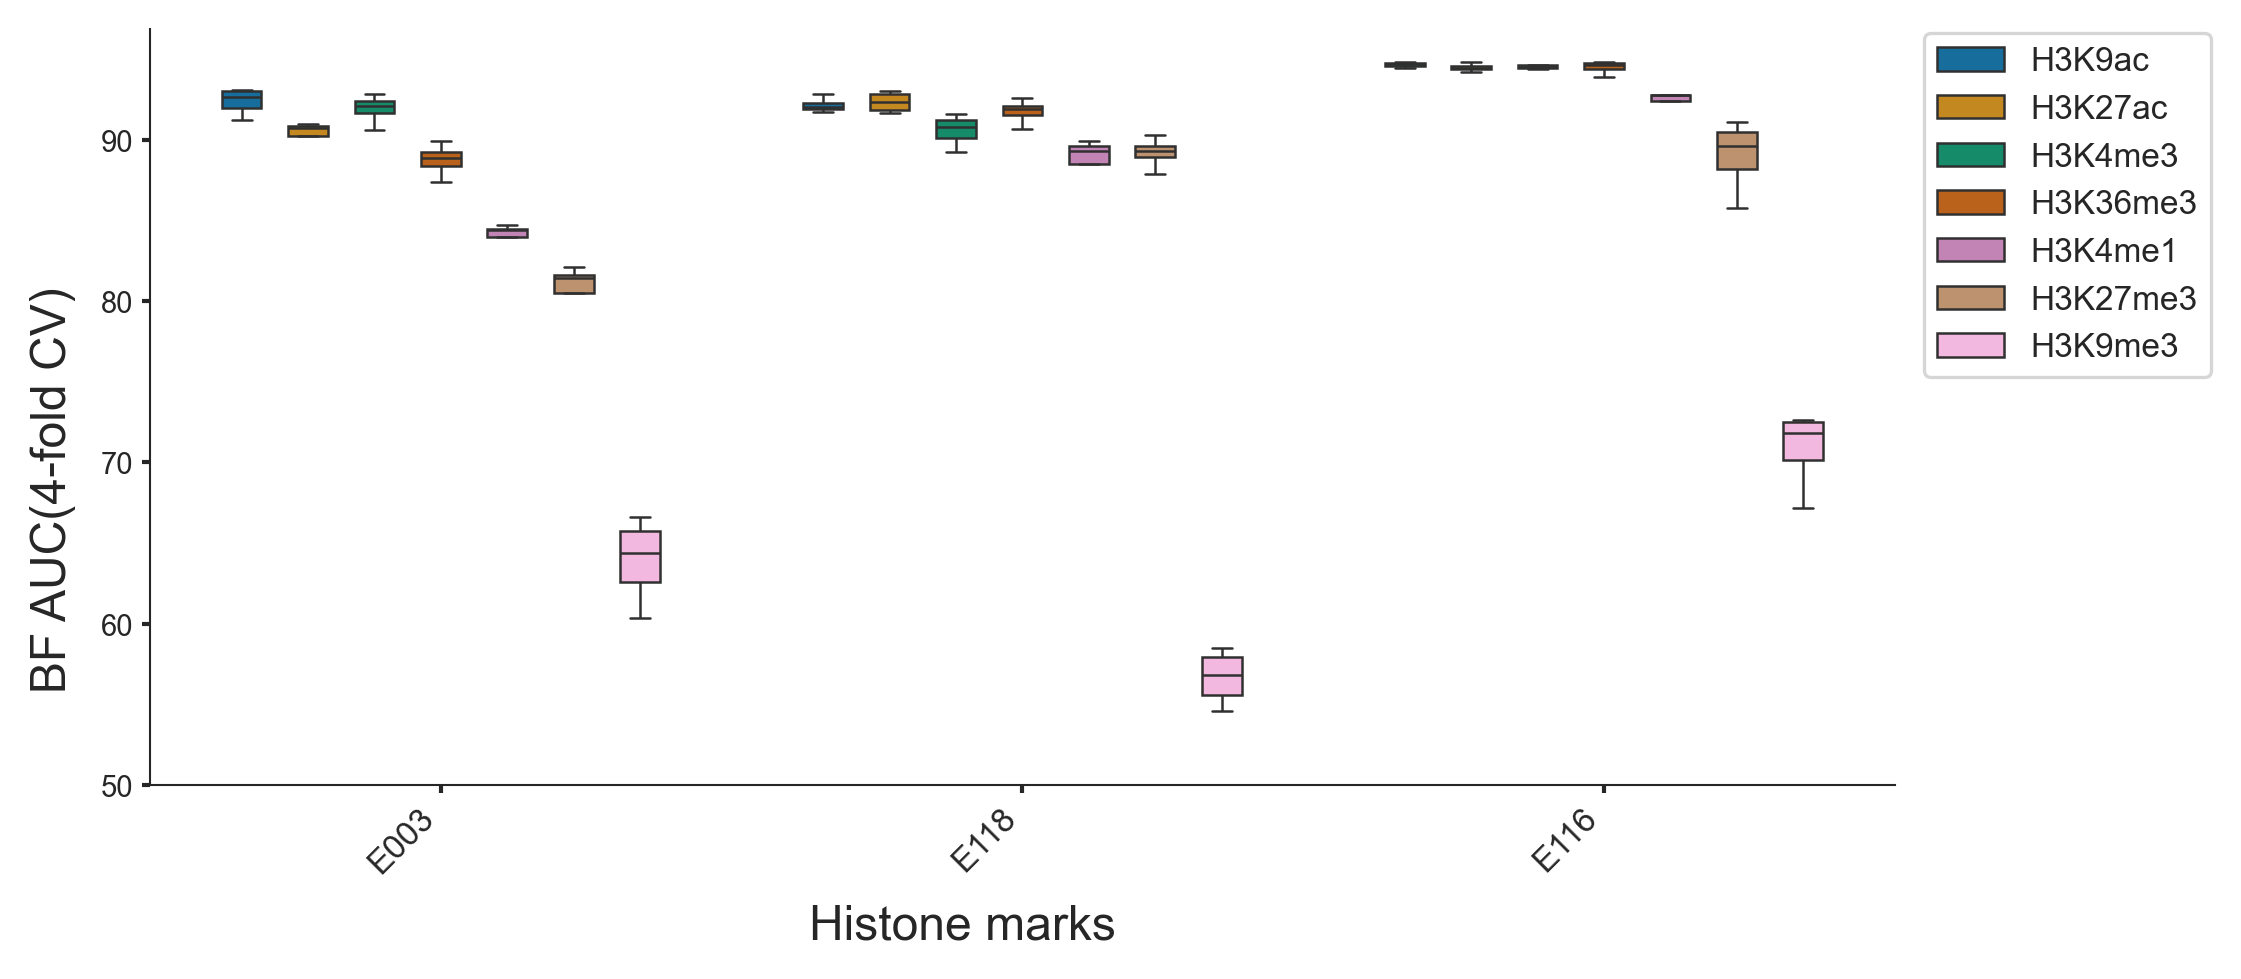

In [14]:


df = data[data['target'] == 'bf_label']
# fig=plt.figure(figsize=(3.6,3.6) , dpi= 300, facecolor='w', edgecolor='k')
# fig.tight_layout(pad = 1)
fig, ax = plt.subplots(1,1,constrained_layout=True)
hue_order = pd.Index(["H3K9ac","H3K27ac","H3K4me3","H3K36me3","H3K4me1","H3K27me3","H3K9me3"],name='marks')
order = pd.Index(["E003","E118","E116"],name='marks')
ax = sns.boxplot(data=df,y='auc',x='eid',hue='keep_mark',gap=0.4,width=0.8,fliersize=0,order=order,hue_order=hue_order,linewidth=0.6)
ax.set_xlabel('')
ax.set_ylabel('')

fig.supylabel(f'BF AUC(4-fold CV)')
fig.supxlabel(f'Histone marks')
# ax.set_ylim(top=4)
ax.legend().remove()
ax.set_ylim(bottom=50)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right',fontdict={'size':8})  # ha参数用于设置水平对齐方式
fig.legend(loc='upper left', bbox_to_anchor=(1, 1))  # Moves the legend outside the 
plt.savefig('extra/datasets/benchmark/Promoterformer/figures/Figure3.d.eps', format='eps', bbox_inches='tight')
plt.show()